# Laboratorio 5 - Análisis de paquetes y detección de anomalías
## Security Data Science
### Edwin Andrés Ortega Kou - 22305

### Scapy 

In [1]:
from scapy.all import * 
import pandas as pd 
import numpy as np
import binascii 
import seaborn as sns
sns.set(color_codes=True)
%matplotlib inline

## Análisis de paquetes

### Carga del archivo PCAP

In [2]:
pcap = rdpcap("data/analisis_paquetes.pcap")

print("Cantidad de paquetes:", len(pcap))
print("Tipo de objeto:", type(pcap))

Cantidad de paquetes: 62
Tipo de objeto: <class 'scapy.plist.PacketList'>


### Inspección inicial del archivo

In [3]:
# Ver el primer paquete:
pcap[0]

<Ether  dst=80:37:73:96:9b:db src=88:e9:fe:6a:92:52 type=IPv4 |<IP  version=4 ihl=5 tos=0x0 len=961 id=1 flags= frag=0 ttl=64 proto=udp chksum=0x52e6 src=10.1.10.53 dst=84.54.22.33 |<UDP  sport=domain dport=domain len=941 chksum=0xf60e |<DNS  id=12 qr=0 opcode=QUERY aa=0 tc=0 rd=1 ra=0 z=0 ad=0 cd=0 rcode=ok qdcount=1 ancount=0 nscount=0 arcount=0 qd=[<DNSQR  qname=b'google.com.' qtype=AAAA unicastresponse=0 qclass=IN |>] |<Raw  load=b'\xef\xbf\xbdPNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01b\x00\x00\x00\xef\xbf\xbd\x08\x06\x00\x00\x00(\xef\xbf\xbdTR\x00\x00:\xef\xbf\xbdIDATx\xef\xbf\xbd\xef\xbf\xbd\t|T\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd\xef\xbf\xbd;K\x12\x08;\x08\xef\xbf\xbd\nE\xef\xbf\xbd\xef\xbf\xbd$\x19\xef\xbf\xbd\xef\xbf\xbdZi\xdf\xaa-\xef\xbf\xbd;N2\xef\xbf\xbd\xef\xbf\xbdV\xef\xbf\xbdV\xef\xbf\xbda\xef\xbf\xbdZ\x11!\xef\xbf\xbd\xef\xbf\xbd\x01\xdc\xbbik[\xef\xbf\xbd.ok\xef\xbf\xbde\xef\xbf\xbd\x01\\\xef\xbf\xbd\xef\xbf\xbd]\xef\xbf\xbd-\xef\xbf\xbd\xef\xbf\xbd\xef\x

In [4]:
# Resumen corto del primer paquete
pcap[0].summary()

"Ether / IP / UDP / DNS Qry b'google.com.' / Raw"

### Análisis del primer paquete

In [5]:
ethernet_frame = pcap[0]
ip_packet = ethernet_frame.payload
segment = ip_packet.payload
data = segment.payload

print("Capa de enlace:", type(ethernet_frame))
print("Capa de red:", type(ip_packet))
print("Capa de transporte:", type(segment))
print("Payload:", type(data))

Capa de enlace: <class 'scapy.layers.l2.Ether'>
Capa de red: <class 'scapy.layers.inet.IP'>
Capa de transporte: <class 'scapy.layers.inet.UDP'>
Payload: <class 'scapy.layers.dns.DNS'>


### Visualización en hexadecimal

In [6]:
hexdump(pcap[0])

0000  80 37 73 96 9B DB 88 E9 FE 6A 92 52 08 00 45 00  .7s......j.R..E.
0010  03 C1 00 01 00 00 40 11 52 E6 0A 01 0A 35 54 36  ......@.R....5T6
0020  16 21 00 35 00 35 03 AD F6 0E 00 0C 01 00 00 01  .!.5.5..........
0030  00 00 00 00 00 00 06 67 6F 6F 67 6C 65 03 63 6F  .......google.co
0040  6D 00 00 1C 00 01 EF BF BD 50 4E 47 0D 0A 1A 0A  m........PNG....
0050  00 00 00 0D 49 48 44 52 00 00 01 62 00 00 00 EF  ....IHDR...b....
0060  BF BD 08 06 00 00 00 28 EF BF BD 54 52 00 00 3A  .......(...TR..:
0070  EF BF BD 49 44 41 54 78 EF BF BD EF BF BD 09 7C  ...IDATx.......|
0080  54 EF BF BD EF BF BD EF BF BD EF BF BD EF BF BD  T...............
0090  3B 4B 12 08 3B 08 EF BF BD 0A 45 EF BF BD EF BF  ;K..;.....E.....
00a0  BD 24 19 EF BF BD EF BF BD 5A 69 DF AA 2D EF BF  .$.......Zi..-..
00b0  BD 3B 4E 32 EF BF BD EF BF BD 56 EF BF BD 56 EF  .;N2......V...V.
00c0  BF BD 61 EF BF BD 5A 11 21 EF BF BD EF BF BD 01  ..a...Z.!.......
00d0  DC BB 69 6B 5B EF BF BD 2E 6F 6B EF BF BD 65 EF  ..ik[....

### Campos disponibles en el paquete

In [7]:
ls(pcap[0])

dst        : DestMACField                        = '80:37:73:96:9b:db' ('None')
src        : SourceMACField                      = '88:e9:fe:6a:92:52' ('None')
type       : XShortEnumField                     = 2048            ('36864')
--
version    : BitField  (4 bits)                  = 4               ('4')
ihl        : BitField  (4 bits)                  = 5               ('None')
tos        : XByteField                          = 0               ('0')
len        : ShortField                          = 961             ('None')
id         : ShortField                          = 1               ('1')
flags      : FlagsField                          = <Flag 0 ()>     ('<Flag 0 ()>')
frag       : BitField  (13 bits)                 = 0               ('0')
ttl        : ByteField                           = 64              ('64')
proto      : ByteEnumField                       = 17              ('0')
chksum     : XShortField                         = 21222           ('None')
src       

### Resumen del paquete analizado

In [8]:
print(pcap[0].summary())

Ether / IP / UDP / DNS Qry b'google.com.' / Raw


## Testeo de la herramienta

### Capturas los 10 paquetes

In [9]:
pcap_test = sniff(count=10)

print("Tipo de dato:", type(pcap_test))
print("Cantidad de paquetes capturados:", len(pcap_test))

Tipo de dato: <class 'scapy.plist.PacketList'>
Cantidad de paquetes capturados: 10


### Muestras del contenido general

In [10]:
pcap_test.summary()

Ether / IP / TCP 192.168.58.106:55603 > 104.208.16.90:https A
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw
Ether / IP / TCP 104.208.16.90:https > 192.168.58.106:55603 PA / Raw
Ether / IP / TCP 192.168.58.106:55603 > 104.208.16.90:https PA / Raw
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw
Ether / IP / UDP 192.168.58.106:58042 > 104.29.135.222:19328 / Raw


### Interpretación

In [11]:
data_test = []

for pkt in pcap_test:
    if IP in pkt:
        src_port = None
        dst_port = None
        
        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport

        data_test.append({
            "Src Address": pkt[IP].src,
            "Dst Address": pkt[IP].dst,
            "Src Port": src_port,
            "Dst Port": dst_port
        })

df_test = pd.DataFrame(data_test)
df_test

,Src Address,Dst Address,Src Port,Dst Port
0,192.168.58.106,104.208.16.90,55603,443
1,192.168.58.106,104.29.135.222,58042,19328
2,192.168.58.106,104.29.135.222,58042,19328
3,104.208.16.90,192.168.58.106,443,55603
4,192.168.58.106,104.208.16.90,55603,443
5,192.168.58.106,104.29.135.222,58042,19328
6,192.168.58.106,104.29.135.222,58042,19328
7,192.168.58.106,104.29.135.222,58042,19328
8,192.168.58.106,104.29.135.222,58042,19328
9,192.168.58.106,104.29.135.222,58042,19328


### Observación

La tabla anterior resume información básica de conectividad entre hosts. Las direcciones IP permiten identificar el origen y destino de la comunicación, mientras que los puertos ayudan a inferir qué servicios o aplicaciones están participando en el tráfico capturado.

### Validación de la captura en tráfico real

In [14]:
df_test.describe(include='all')

,Src Address,Dst Address,Src Port,Dst Port
count,10,10,10.000000,10.000000
unique,2,3,NaN,NaN
top,192.168.58.106,104.29.135.222,NaN,NaN
freq,9,7,NaN,NaN
mean,NaN,NaN,51794.300000,19178.500000
std,NaN,NaN,18071.477496,15014.580219
min,NaN,NaN,443.000000,443.000000
25%,NaN,NaN,56212.750000,19328.000000
50%,NaN,NaN,58042.000000,19328.000000
75%,NaN,NaN,58042.000000,19328.000000


In [15]:
df_test["Dst Port"].value_counts()

Dst Port
19328    7
443      2
55603    1
Name: count, dtype: int64

## Estadísticas y detección con Z-Score

### Convertir PCAP a un DataFrame

In [16]:
data = []

for pkt in pcap:
    if IP in pkt:
        src_port = None
        dst_port = None
        payload_len = 0

        if TCP in pkt:
            src_port = pkt[TCP].sport
            dst_port = pkt[TCP].dport
            payload_len = len(pkt[TCP].payload)

        elif UDP in pkt:
            src_port = pkt[UDP].sport
            dst_port = pkt[UDP].dport
            payload_len = len(pkt[UDP].payload)

        data.append({
            "src": pkt[IP].src,
            "dst": pkt[IP].dst,
            "sport": src_port,
            "dport": dst_port,
            "payload_len": payload_len
        })

df = pd.DataFrame(data)

df.head()

,src,dst,sport,dport,payload_len
0,10.1.10.53,84.54.22.33,53,53,933
1,84.54.22.33,10.1.10.53,53,53,56
2,10.1.10.53,84.54.22.33,53,53,947
3,84.54.22.33,10.1.10.53,53,53,56
4,10.1.10.53,84.54.22.33,53,53,984


In [22]:
type(df)

pandas.core.frame.DataFrame

In [24]:
df.columns

Index(['src', 'dst', 'sport', 'dport', 'payload_len'], dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   src          62 non-null     object
 1   dst          62 non-null     object
 2   sport        62 non-null     int64 
 3   dport        62 non-null     int64 
 4   payload_len  62 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.6+ KB


### Estadísticas básicas

#### a. IP origen más frecuente

In [17]:
most_src = df["src"].value_counts().idxmax()
print("IP origen más frecuente:", most_src)

IP origen más frecuente: 10.1.10.53


La IP de origen más frecuente corresponde a una dirección interna de la red. Esto indica que este host es el que más tráfico genera dentro del archivo capturado, consistente con un cliente que realiza múltiples solicitudes en la red.

#### b. IP destino más frecuente

In [18]:
most_dst = df["dst"].value_counts().idxmax()
print("IP destino más frecuente:", most_dst)

IP destino más frecuente: 10.1.10.53


La IP destino más frecuente es una dirección externa. Eso dice que el tráfico está dirigido principalmente hacia un servidor específico, lo cual es típico en comunicaciones como consultas DNS o acceso a servicios externos.

#### c. ¿A qué IPs se comunica la IP del inciso a?

In [19]:
df[df["src"] == most_src]["dst"].unique()

array(['84.54.22.33', '75.75.75.75'], dtype=object)

La IP origen más frecuente se comunica principalmente con una o pocas direcciones IP externas. En este caso, se observa que la comunicación se da principalmente con un servidor específico, lo cual refuerza la idea de que se trata de tráfico dirigido, como consultas DNS hacia un servidor resolutor.

#### d. ¿A qué puertos destino se comunica la IP del inciso a?

In [20]:
df[df["src"] == most_src]["dport"].value_counts()

dport
53    31
Name: count, dtype: int64

La IP origen más frecuente se comunica principalmente al puerto 53, lo cual indica tráfico DNS. Este puerto es utilizado para la resolución de nombres de dominio, lo que sugiere que el host está realizando consultas DNS.

#### e. ¿A qué puertos origen se comunica la IP del inciso b?

In [21]:
df[df["dst"] == most_dst]["sport"].value_counts()

sport
53    31
Name: count, dtype: int64

La IP destino más frecuente también utiliza el puerto 53 como puerto origen en las respuestas. Esto es consistente con el comportamiento de un servidor DNS, que responde desde el mismo puerto al que recibió la solicitud.

#### f. Propósito de los puertos

Análisis de puertos

Los puertos más frecuentes observados corresponden a servicios conocidos:

- 80: HTTP
- 443: HTTPS
- 53: DNS

Esto indica que el tráfico capturado corresponde principalmente a navegación web y resolución de nombres de dominio.

### Z-Score sobre el tamaño de payload

#### a. Calcular Z-score

In [26]:
mean_payload = df["payload_len"].mean()
std_payload = df["payload_len"].std()

df["z_score"] = (df["payload_len"] - mean_payload) / std_payload

df[np.abs(df["z_score"]) > 2]

,src,dst,sport,dport,payload_len,z_score


Al aplicar el Z-score utilizando la media y desviación estándar del dataset, no se detectaron paquetes con |Z| > 2. Esto indica que, desde una perspectiva puramente estadística, no hay valores extremos.

Sin embargo, esto puede deberse a que la distribución de los datos no es normal y presenta valores altos de forma frecuente, lo cual incrementa la media y la desviación estándar. Como resultado, el método pierde sensibilidad para detectar anomalías reales.

#### b. Histograma

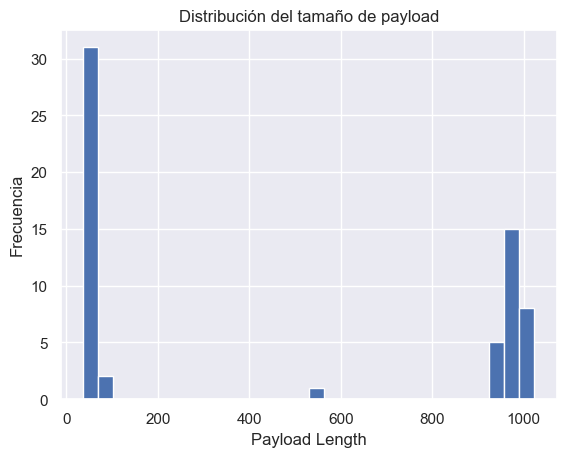

In [27]:
import matplotlib.pyplot as plt

plt.hist(df["payload_len"], bins=30)
plt.title("Distribución del tamaño de payload")
plt.xlabel("Payload Length")
plt.ylabel("Frecuencia")
plt.show()

Se observa que la distribución no es normal. En particular, hay una mezcla de paquetes pequeños y paquetes mucho más grandes. Debido a esta distribución, la media y la desviación estándar aumentan, lo que hace que los valores grandes no sean considerados anomalías por el Z-score. Esto explica por qué el método no detectó valores anómalos en el inciso anterior.

#### c. Z-score con DNS

In [28]:
mean_dns = 50
std_dns = 15

df["z_score_dns"] = (df["payload_len"] - mean_dns) / std_dns

df[np.abs(df["z_score_dns"]) > 2]

,src,dst,sport,dport,payload_len,z_score,z_score_dns
0,10.1.10.53,84.54.22.33,53,53,933,0.981296,58.866667
2,10.1.10.53,84.54.22.33,53,53,947,1.011713,59.800000
4,10.1.10.53,84.54.22.33,53,53,984,1.092101,62.266667
6,10.1.10.53,84.54.22.33,53,53,970,1.061684,61.333333
8,10.1.10.53,84.54.22.33,53,53,975,1.072547,61.666667
10,10.1.10.53,84.54.22.33,53,53,1017,1.163798,64.466667
12,10.1.10.53,84.54.22.33,53,53,980,1.083410,62.000000
14,10.1.10.53,84.54.22.33,53,53,951,1.020404,60.066667
16,10.1.10.53,84.54.22.33,53,53,931,0.976951,58.733333
18,10.1.10.53,84.54.22.33,53,53,964,1.048648,60.933333


Al aplicar el Z-score utilizando valores típicos de tráfico DNS, se detectan múltiples paquetes con valores de |Z| > 2. En particular, los paquetes con tamaños cercanos a 900–1000 bytes son claramente identificados como anomalías. Esto indica que, aunque el dataset no mostraba anomalías desde una perspectiva global, sí existen comportamientos inusuales cuando se analiza con conocimiento del protocolo.

#### d. ¿Qué puede decir que nos enseña esto sobre la importancia de conocer el o los protocolos a analizar al aplicar técnicas de detección de anomalías?

Este ejercicio demuestra que el uso de técnicas estadísticas como el Z-score depende fuertemente del conocimiento del dominio. Si solo se utilizan estadísticas del dataset, es posible que las anomalías no sean detectadas debido a la forma de la distribución de los datos. En cambio, al incorporar conocimiento sobre el comportamiento esperado de un protocolo (como el tamaño típico de paquetes DNS), es posible identificar anomalías de manera más efectiva. Esto resalta la importancia de combinar análisis estadístico con conocimiento del contexto en el análisis de tráfico de red.